# Limpeza dos dados


In [101]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from numpy.polynomial import Polynomial

## Limpeza na base de dados


In [102]:
df = pd.read_csv("ships.csv", encoding="latin1")

raw_cols = ["DWT", "LBP", "B", "D", "d", "Vs"]

df = df[(df[raw_cols] != 0).all(axis=1)].reset_index(drop=True)

# df.to_csv("ships.csv", index=False, encoding="latin1")
# df.head()
df.shape

(5191, 16)

In [103]:
def dedup_by_tolerance(data, tolerances):
    key = pd.DataFrame({col: (data[col] / tol).round() * tol for col, tol in tolerances.items()})
    return data.loc[~key.duplicated()].reset_index(drop=True)

TOLERANCE_TIGHT = {"LBP": 1, "B": 0.1, "D": 0.1, "d": 0.1, "DWT": 100, "Vs": 0.01}
TOLERANCE_LOOSE = {"LBP": 5, "B": 0.5, "D": 0.5, "d": 0.5, "DWT": 500, "Vs": 0.1}

df_dedup_tight = dedup_by_tolerance(df, TOLERANCE_TIGHT)
df_dedup_loose = dedup_by_tolerance(df, TOLERANCE_LOOSE)

print(f"Original: {df.shape[0]} rows")
print(f"Deduplicated (tight): {df_dedup_tight.shape[0]} rows")
print(f"Deduplicated (loose): {df_dedup_loose.shape[0]} rows")

df = df_dedup_loose
df.to_csv("ships_dedup_loose.csv", index=False, encoding="latin1")

Original: 5191 rows
Deduplicated (tight): 3810 rows
Deduplicated (loose): 3077 rows


## Gráficos de dispersão


### Configurações dos gráficos


In [104]:
label_dict = {
    "B": "Breadth [m]",
    "D": "Depth [m]",
    "LBP": "Length Between Perpendiculars [m]",
    "d": "Scantling Draft [m]",
    "Air_d": "Air Draft [m]",
    "DWT": "DWT [t]",
    "Vs": "Speed [m/s]",
}

SCATTER_PAIRS = [
    ("DWT", "LBP"),
    ("DWT", "B"),
    ("DWT", "D"),
    ("DWT", "d"),
    ("DWT", "Air_d"),
    ("DWT", "Vs"),
    ("LBP", "B"),
    ("B", "D"),
    ("LBP", "Vs"),
    #("LBP", "D"),
    #("LBP", "L/B"),
    #("LBP", "B/D"),
    #("LBP", "L/D"),
    #("LBP", "d/D"),
]

# pares (x, y) em que a curva de regressao polinomial (DWT/LBP x dimensao) e mostrada
REGRESSION_PAIRS = {
    ("DWT", "LBP"), ("DWT", "B"), ("DWT", "D"), ("DWT", "d"),
    ("LBP", "B"), ("LBP", "D"), ("B", "D")
}

# coluna -> chave usada nos dicionarios de restricao de porto (valor maximo permitido)
PORT_LIMIT_KEY_MAP = {"LBP": "L", "B": "B", "d": "d"}

# coluna -> chave usada no requisito de projeto
REQ_KEY_MAP = {"DWT": "DWT", "Vs": "Vs"}


RESTRICTION_COLORS = {
    "Panama": "tab:green",
    "Golfo Mex.": "tab:pink",
    "Req_proj": "tab:red",
    #"Suez": "tab:orange",
    #"St_Lawrence": "tab:purple",
}


### Restrições


In [105]:
Suez = {
    "B": 77.5,
    "L": 400,
    "d": 18.89
}

Golfo_Mex = {
    "d": 13.7,
    "Air_d": 53.0
}

Panama = {
    "B": 32.31,
    "L": 289.6,
    "d": 12.04,
    "Air_d": 57.91
}

St_Lawrence = {
    "B": 23.8,
    "L": 222.5,
    "d": 7.92
}

Req_proj = {
    "Vs": 7.87,
    "DWT": 45100,
}

PORT_LIMITS = {
    "Panama": Panama,
    "Golfo Mex.": Golfo_Mex,
    #"Suez": Suez,
    #"St_Lawrence": St_Lawrence,
}


### Regressões TUD 2008


In [106]:
def reg_LBP(DWT):
    return 41.647 * DWT**(0.133)


def reg_B(DWT):
    return min(15.04 + 0.000369 * DWT, 32.2)


def reg_D(DWT):
    return 9.69 + 0.000188 * DWT


def reg_d(DWT):
    return 7.41 + 0.000106 * DWT


# regressoes empiricas TUD 2008 (parametro em funcao do DWT)
TUD_REGRESSIONS = {
    "LBP": reg_LBP,
    "B": reg_B,
    "D": reg_D,
    "d": reg_d,
}

### Plots


In [107]:
def poly_r2(x, y, degree):
    p = Polynomial.fit(x, y, degree)
    y_pred = p(x)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return p, 1 - ss_res / ss_tot


def best_polynomial(x, y, max_degree=10, r2_threshold=0.95):
    """menor grau (<= max_degree) que atinge r2_threshold; senao, o de maior R^2."""
    best_p, best_r2, best_degree = None, -np.inf, None
    for degree in range(1, max_degree + 1):
        p, r2 = poly_r2(x, y, degree)
        if best_p is None or r2 > best_r2:
            best_p, best_r2, best_degree = p, r2, degree
        if r2 >= r2_threshold:
            return p, r2, degree
    return best_p, best_r2, best_degree


def format_polynomial(p, var="x", precision=4):
    """escreve a funcao ajustada (coeficientes na escala original de var) como texto."""
    coeffs = p.convert(domain=[-1, 1], window=[-1, 1]).coef
    terms = []
    for power, c in enumerate(coeffs):
        if power == 0:
            terms.append(f"{c:.{precision}g}")
        elif power == 1:
            terms.append(f"{c:+.{precision}g}*{var}")
        else:
            terms.append(f"{c:+.{precision}g}*{var}^{power}")
    return "y = " + " ".join(terms)

def plot_scatter(sel_df: pd.DataFrame, reg=True):
    for x, y in SCATTER_PAIRS:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(sel_df[x], sel_df[y], color="steelblue",
                edgecolor="black", alpha=0.5, s=15)
        ax.set_xlabel(label_dict.get(x, x))
        ax.set_ylabel(label_dict.get(y, y))
        # ax.set_title(f"{x} x {y}")

        x_min, x_max = sel_df[x].min(), sel_df[x].max()
        y_min, y_max = sel_df[y].min(), sel_df[y].max()

        # restricoes de porto: linha tracejada no valor maximo permitido
        for name, limits in PORT_LIMITS.items():
            color = RESTRICTION_COLORS[name]
            x_key = PORT_LIMIT_KEY_MAP.get(x)
            y_key = PORT_LIMIT_KEY_MAP.get(y)
            if x_key in limits:
                ax.axvline(limits[x_key], color=color, linestyle="--", label=name)
                x_max = max(x_max, limits[x_key])
            if y_key in limits:
                ax.axhline(limits[y_key], color=color, linestyle="--", label=name)
                y_max = max(y_max, limits[y_key])

        # requisito de projeto: linha tracejada no valor alvo
        x_req_key = REQ_KEY_MAP.get(x)
        y_req_key = REQ_KEY_MAP.get(y)
        if x_req_key in Req_proj:
            ax.axvline(Req_proj[x_req_key], color=RESTRICTION_COLORS["Req_proj"],
                    linestyle=":", label="Requisitos de projeto")
            x_max = max(x_max, Req_proj[x_req_key])
        if y_req_key in Req_proj:
            ax.axhline(Req_proj[y_req_key], color=RESTRICTION_COLORS["Req_proj"],
                    linestyle=":", label="Requisitos de projeto")
            y_max = max(y_max, Req_proj[y_req_key])

        regression_eq = None
        if reg:
            # regressao polinomial (grau <= 10, buscando R^2 >= 0.95)
            if (x, y) in REGRESSION_PAIRS:
                x_data = sel_df[x].to_numpy(dtype=float)
                y_data = sel_df[y].to_numpy(dtype=float)
                p, r2, degree = best_polynomial(x_data, y_data)
                x_line = np.linspace(x_data.min(), x_data.max(), 200)
                ax.plot(
                    x_line, p(x_line), color="black", linewidth=2,
                    label=f"Regressão grau {degree} (R²={r2:.3f})",
                )
                regression_eq = format_polynomial(p, var=x)

            # regressao empirica TUD 2008 (parametro em funcao do DWT)
            if x == "DWT" and y in TUD_REGRESSIONS:
                dwt_line = np.linspace(sel_df[x].min(), sel_df[x].max(), 200)
                tud_values = np.array([TUD_REGRESSIONS[y](v) for v in dwt_line])
                ax.plot(dwt_line, tud_values, color="purple", linewidth=2,
                        linestyle="-.", label="Regressão TUD (2008)")
                y_max = max(y_max, tud_values.max())

        handles, labels = ax.get_legend_handles_labels()
        if labels:
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

        if regression_eq:
            print(f"{x} x {y} -> {regression_eq}")


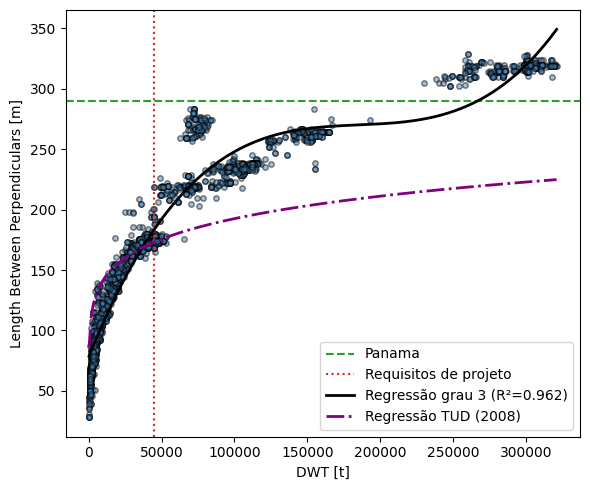

DWT x LBP -> y = 77.98 +0.00301*DWT -1.598e-08*DWT^2 +2.876e-14*DWT^3


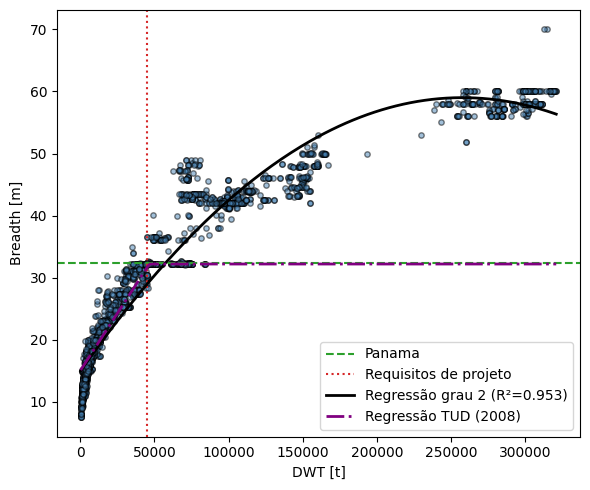

DWT x B -> y = 14.9 +0.0003423*DWT -6.641e-10*DWT^2


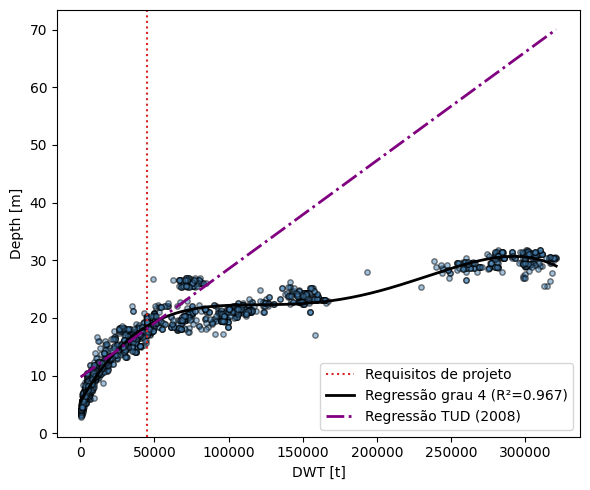

DWT x D -> y = 5.39 +0.0004656*DWT -4.659e-09*DWT^2 +1.957e-14*DWT^3 -2.762e-20*DWT^4


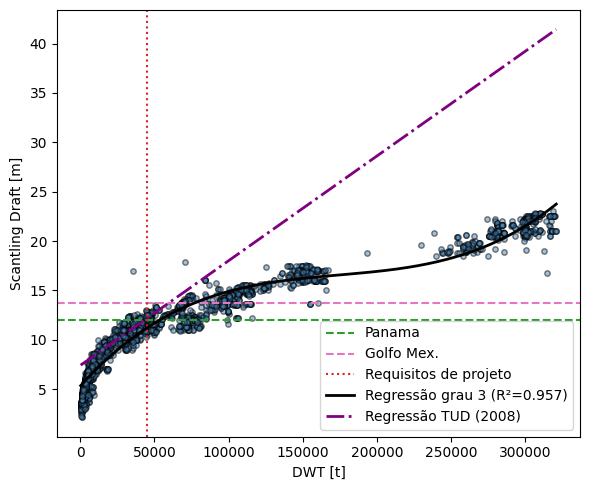

DWT x d -> y = 5.319 +0.0001673*DWT -8.836e-10*DWT^2 +1.686e-15*DWT^3


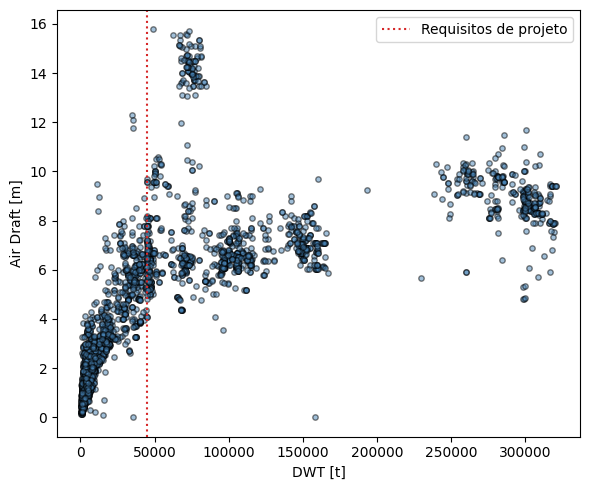

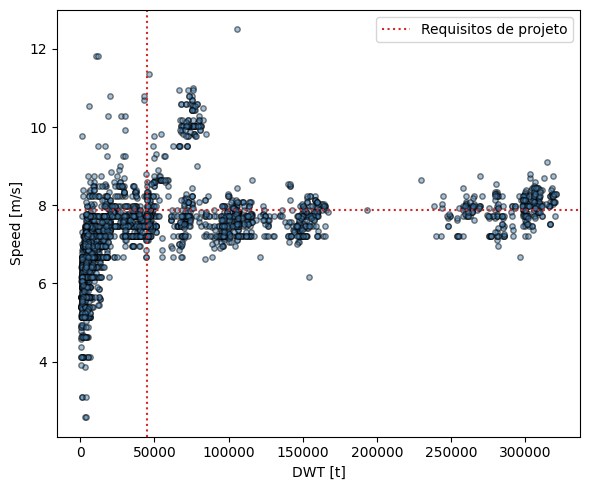

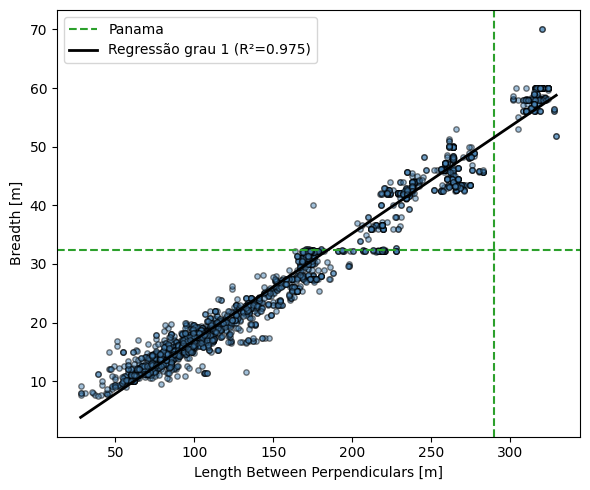

LBP x B -> y = -1.301 +0.1825*LBP


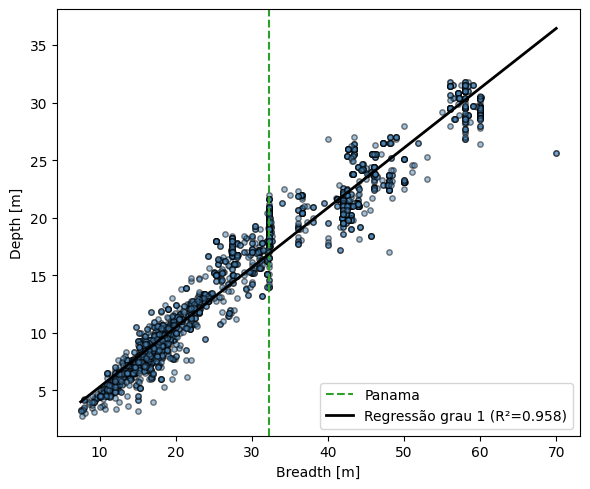

B x D -> y = 0.114 +0.5189*B


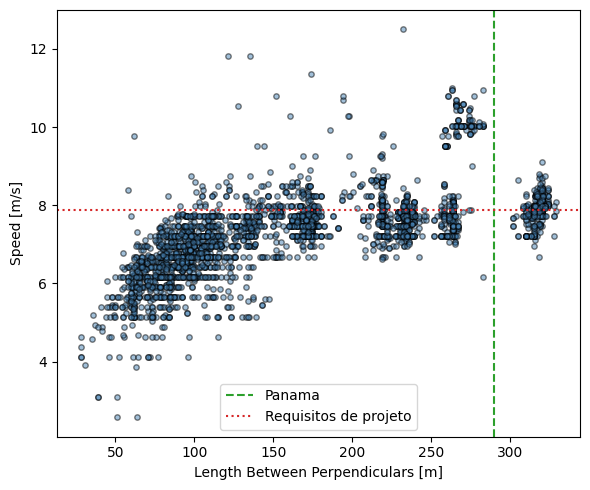

In [108]:
plot_scatter(df)

(251, 16)


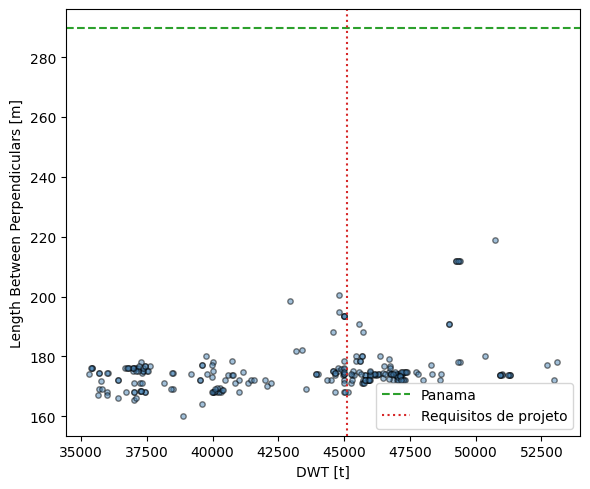

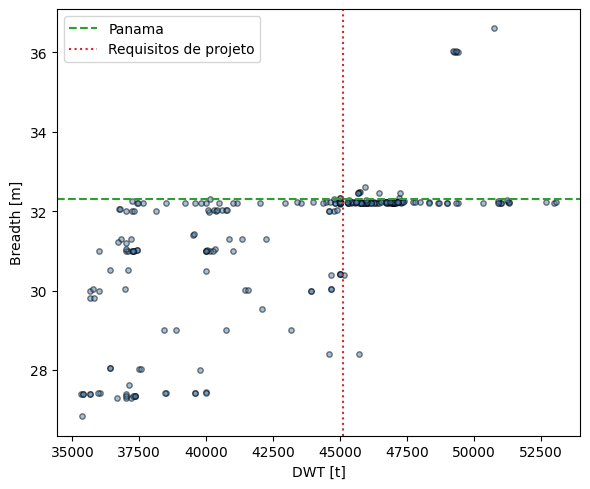

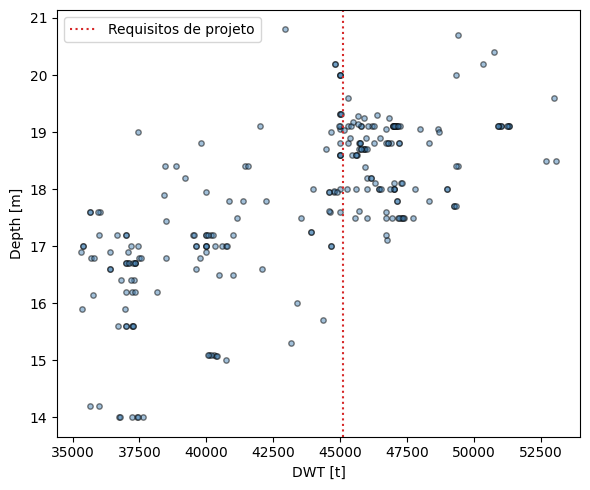

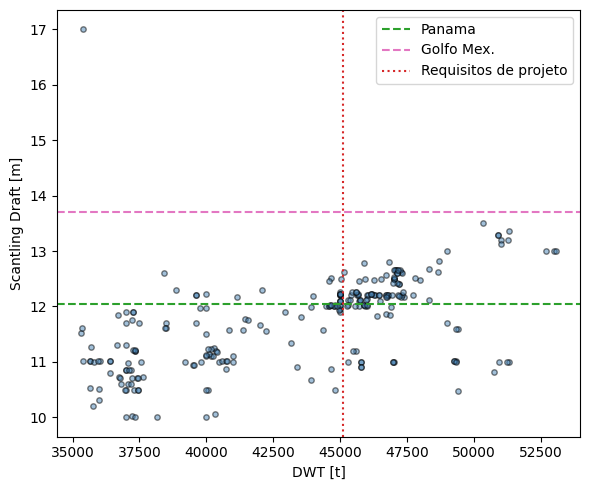

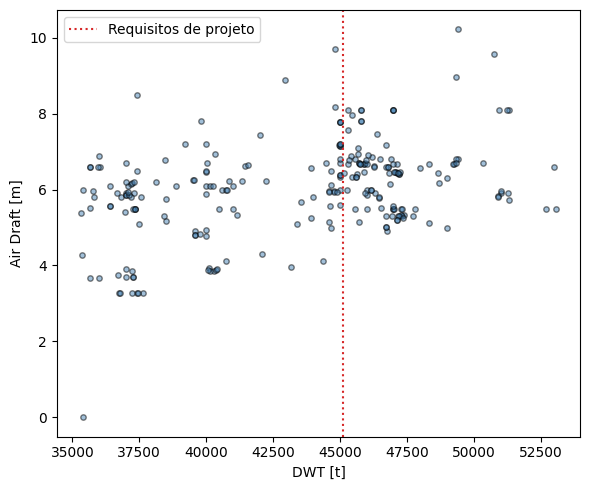

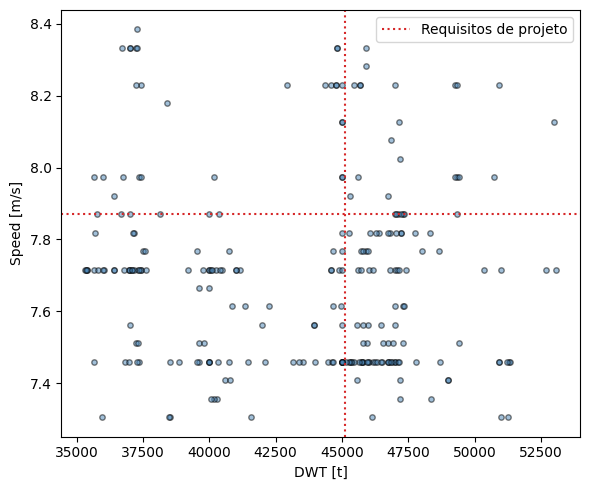

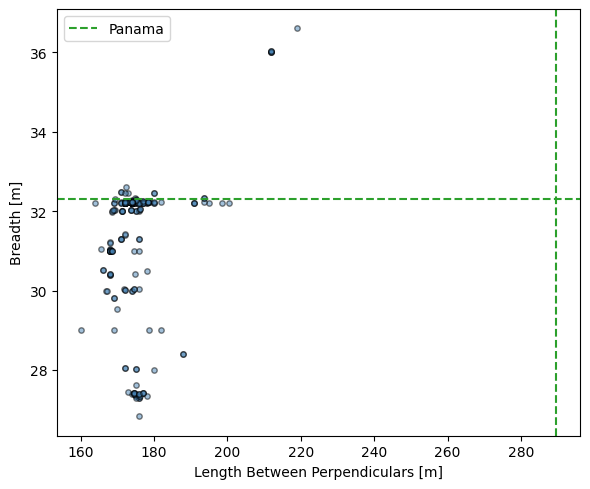

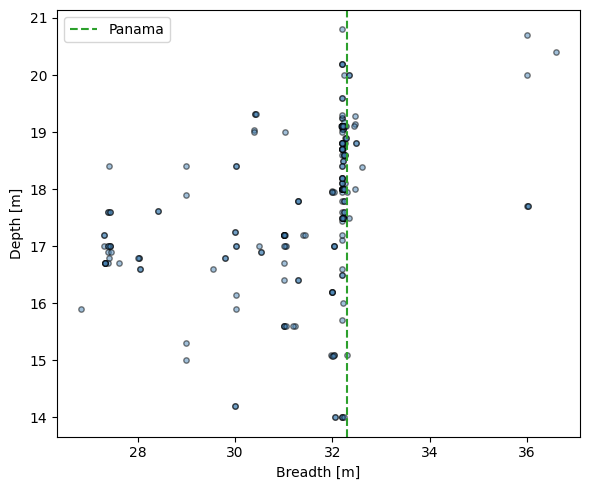

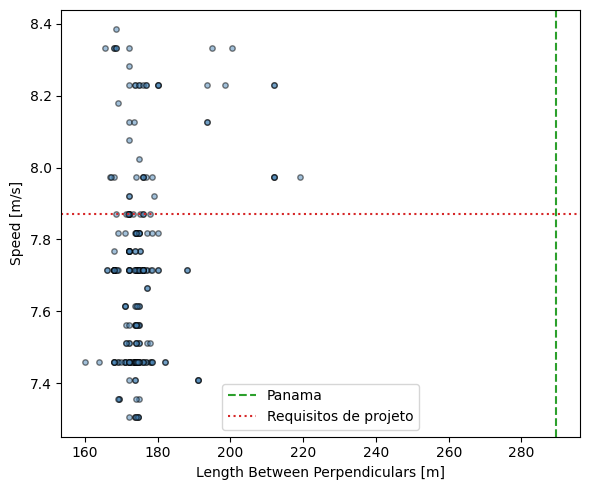

In [109]:
local_DWT=[35100, 55100]
local_Vs=[Req_proj["Vs"]-0.6, Req_proj["Vs"]+0.6]

df_local = df[(df["DWT"] >= local_DWT[0]) & (df["DWT"] <= local_DWT[1]) & (df["Vs"] >= local_Vs[0]) & (df["Vs"] <= local_Vs[1])].reset_index(drop=True)
print(df_local.shape)

plot_scatter(df_local, reg=False)

### Análise estatística


In [110]:
numeric_cols = df_local.select_dtypes(include=np.number).columns.tolist()


def mode_of(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan


stats_rows = {}
for col in numeric_cols:
    s = df_local[col].dropna()
    mean = s.mean()
    std = s.std(ddof=1)
    stats_rows[col] = {
        "media": mean,
        "mediana": s.median(),
        "max": s.max(),
        "min": s.min(),
        "moda": mode_of(s),
        "faixa": s.max() - s.min(),
        "erro padrao": stats.sem(s),
        "variancia": s.var(ddof=1),
        "desv pad": std,
        "coef variancia": std / mean if mean != 0 else np.nan,
        "skewness": stats.skew(s),
        "kurtosis": stats.kurtosis(s),
    }

stats_df = pd.DataFrame(stats_rows)
stats_df


,DWT,LBP,B,D,d,Air_d,Vs,L/B,L/D,B/D,B/d,L/d,d/D,Fr
media,4.338279e+04,175.122506,31.382618,17.776717,11.735988,6.040729,7.705343,5.594520,9.903374,1.773731,2.685618,14.995552,0.662577,0.185999
mediana,4.499500e+04,174.000000,32.200001,17.950001,11.969000,6.099999,7.716000,5.423855,9.749303,1.739130,2.655624,14.619634,0.659574,0.185696
max,5.308200e+04,219.000000,36.599998,20.799999,17.000000,10.220001,8.384720,6.618092,12.635714,2.303571,3.435115,20.230947,1.000000,0.206815
min,3.530900e+04,160.000000,26.833000,14.000000,10.000000,0.000000,7.304480,5.093168,8.695652,1.490217,1.611765,10.352941,0.506280,0.171125
moda,3.700000e+04,172.000000,32.200001,19.100000,11.000000,5.500000,7.458800,5.341615,9.104712,1.685864,2.927273,15.809090,0.575916,0.180586
faixa,1.777300e+04,59.000000,9.766998,6.799999,7.000000,10.220001,1.080240,1.524925,3.940061,0.813354,1.823350,9.878006,0.493720,0.035691
erro padrao,2.864757e+02,0.500073,0.110480,0.085774,0.052266,0.077909,0.016808,0.022343,0.051328,0.009399,0.014145,0.080303,0.003291,0.000422
variancia,2.059916e+07,62.768255,3.063673,1.846670,0.685653,1.523506,0.070907,0.125301,0.661281,0.022174,0.050220,1.618602,0.002719,0.000045
desv pad,4.538629e+03,7.922642,1.750335,1.358923,0.828042,1.234304,0.266283,0.353979,0.813192,0.148908,0.224098,1.272243,0.052146,0.006681
coef variancia,1.046182e-01,0.045241,0.055774,0.076444,0.070556,0.204330,0.034558,0.063272,0.082113,0.083952,0.083444,0.084841,0.078702,0.035917


In [111]:
stats_df.to_csv("ships_stats.csv", index=True, encoding="latin1")

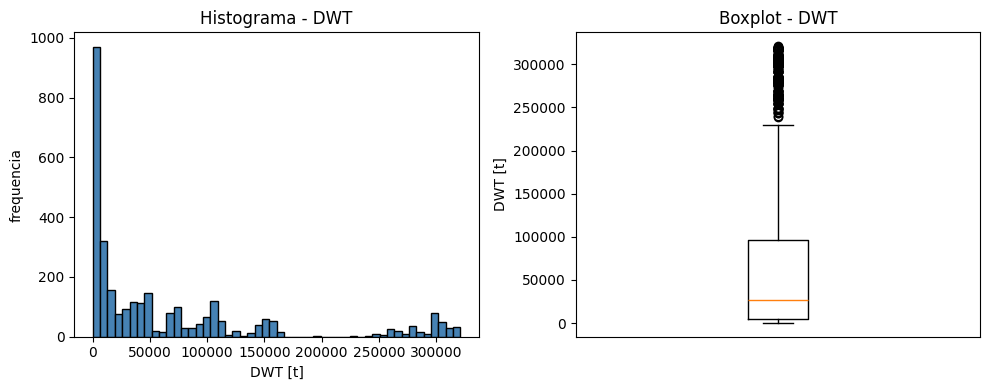

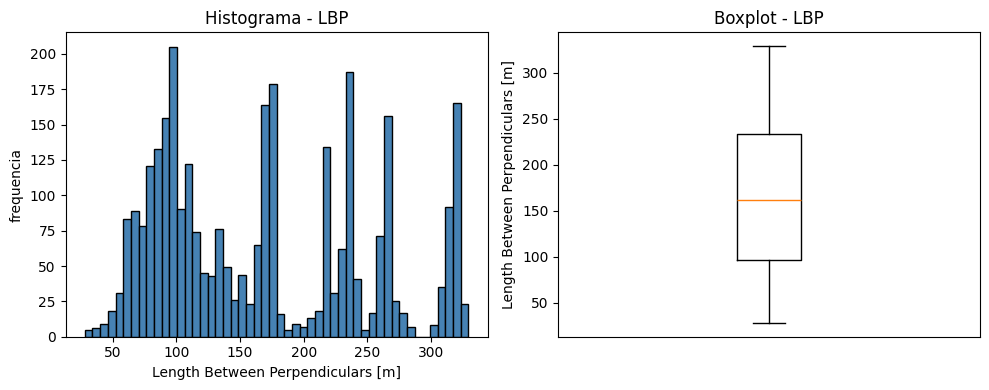

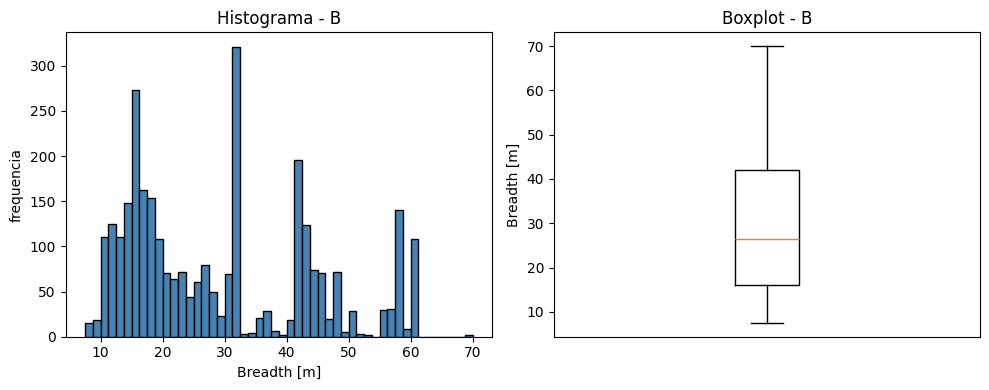

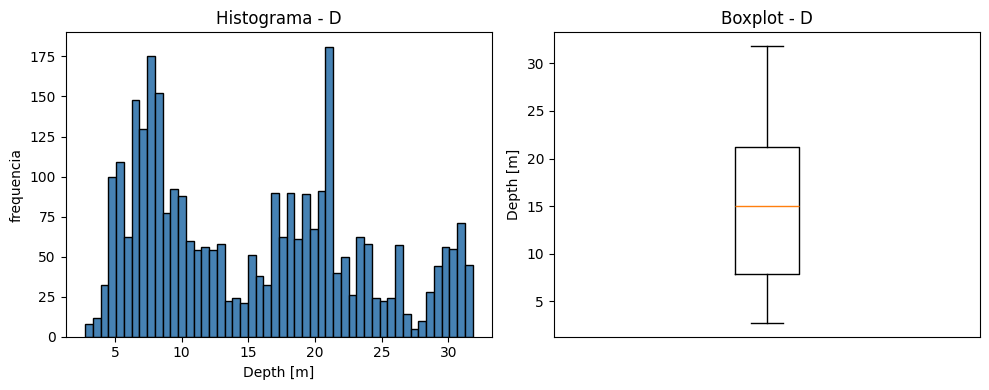

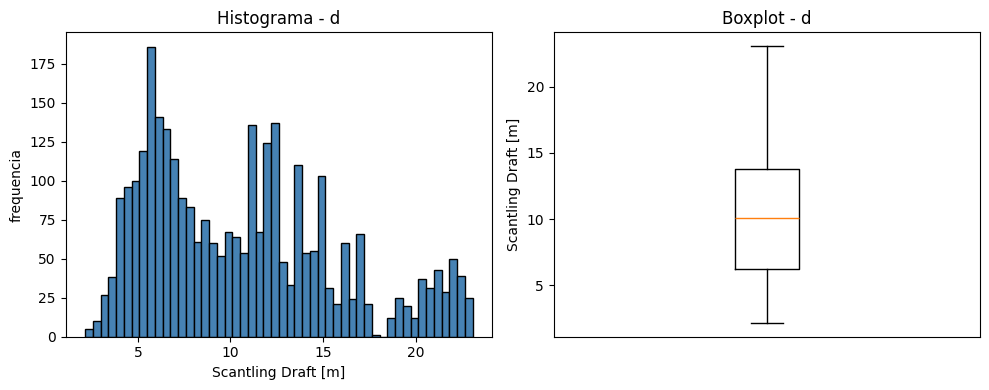

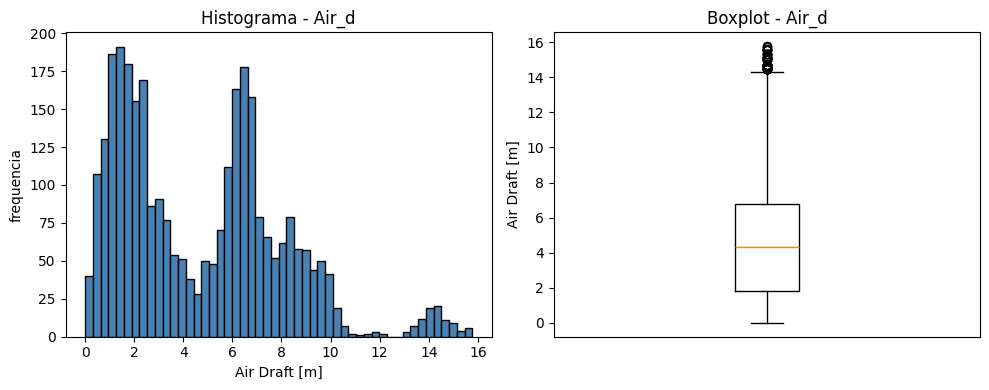

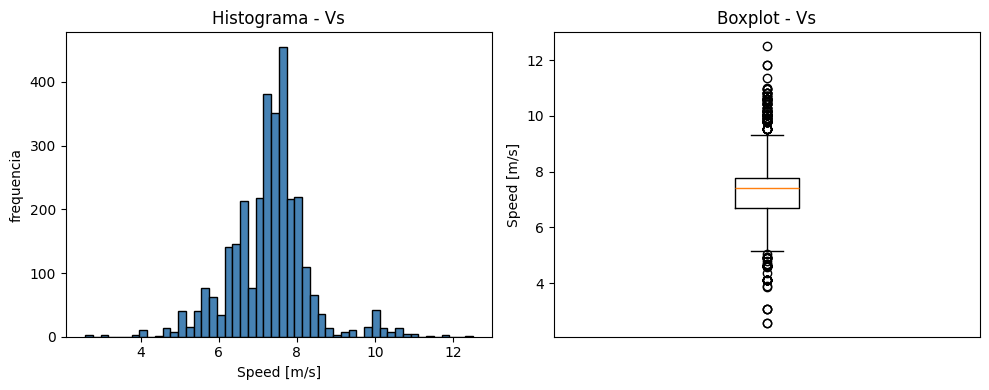

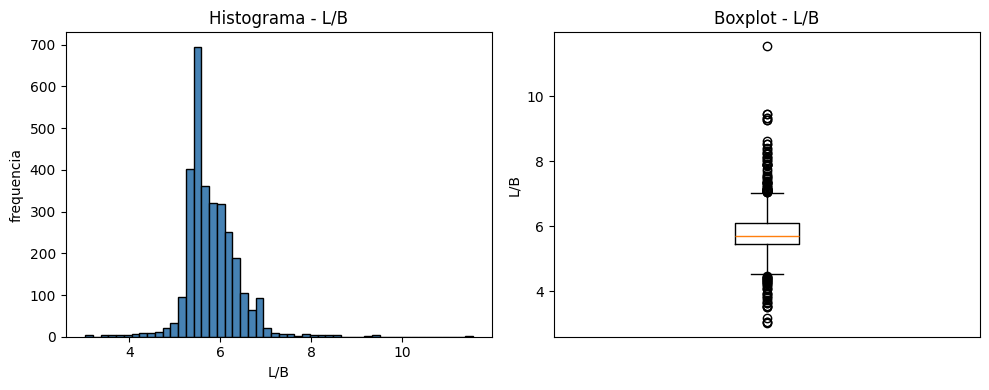

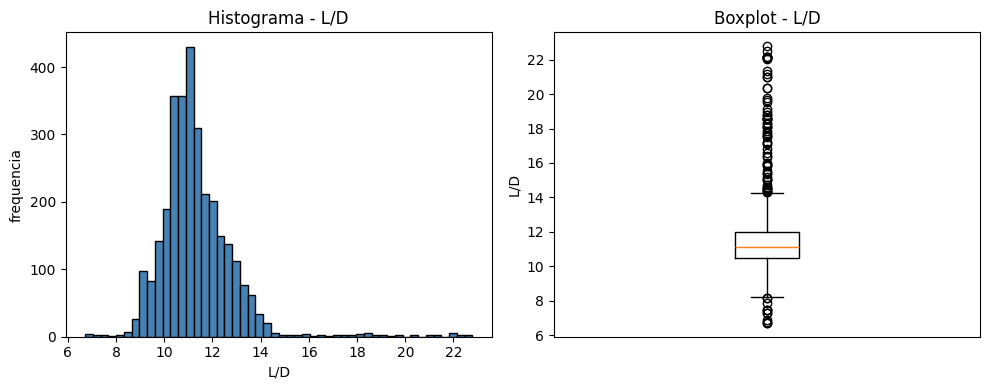

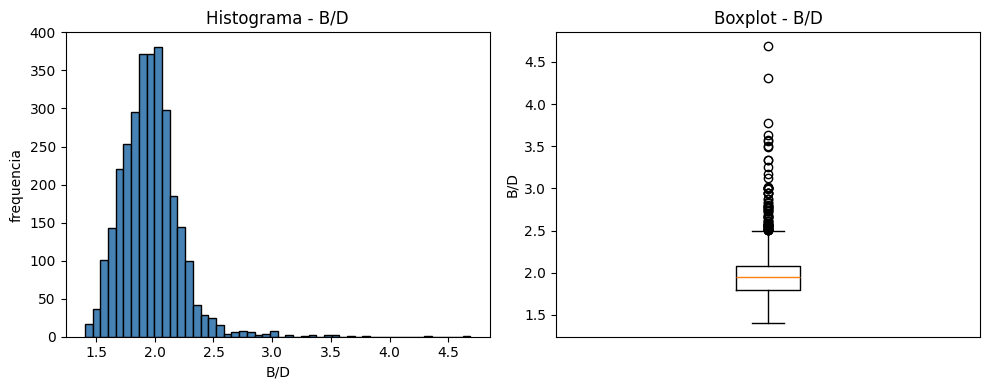

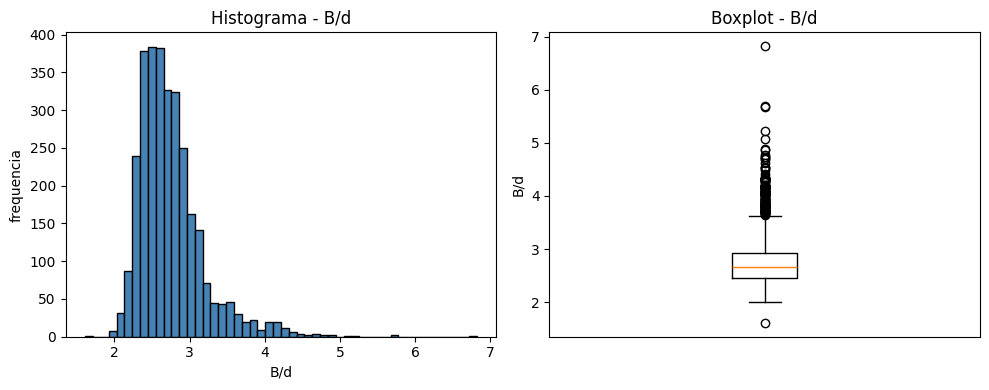

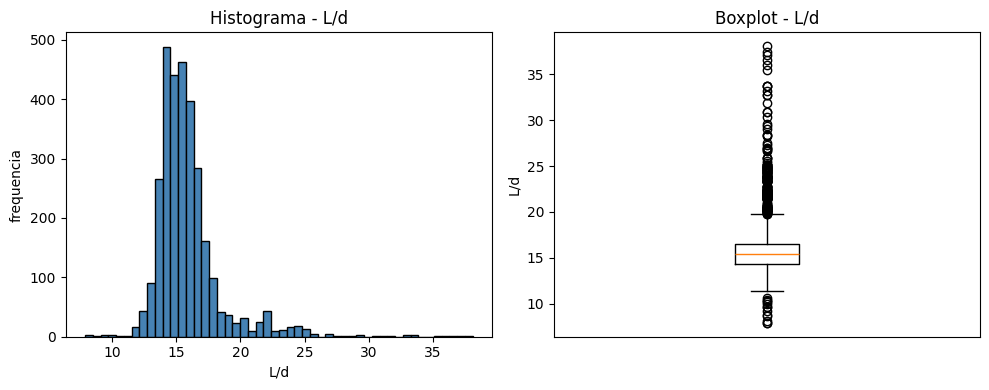

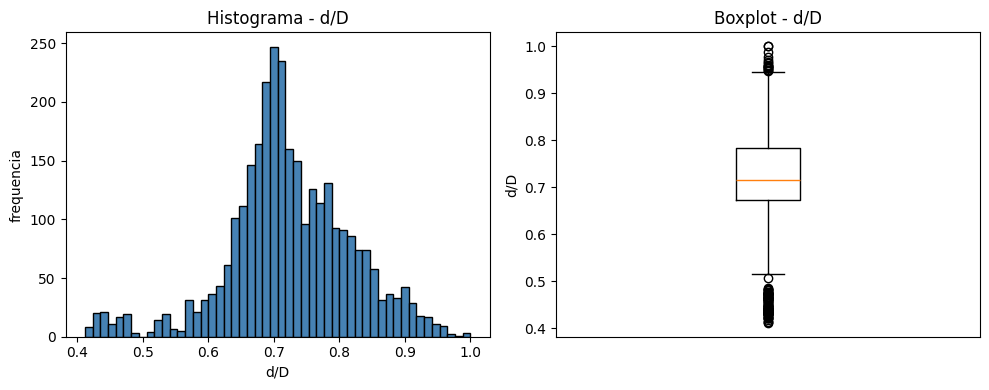

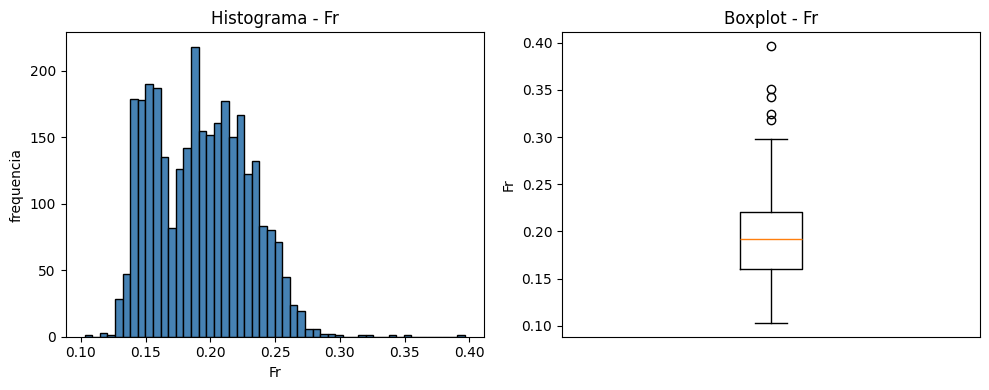

In [112]:
for col in numeric_cols:
    s = df[col].dropna()
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4))
 
    ax_hist.hist(s, bins=50, color="steelblue", edgecolor="black")
    ax_hist.set_xlabel(label_dict.get(col, col))
    ax_hist.set_ylabel("frequencia")
    ax_hist.set_title(f"Histograma - {col}")

    ax_box.boxplot(s, vert=True)
    ax_box.set_ylabel(label_dict.get(col, col))
    ax_box.set_title(f"Boxplot - {col}")
    ax_box.set_xticks([])

    plt.tight_layout()
    plt.show()
